
#Download and Inspect the Structure


In [1]:
import os
import kagglehub

path = kagglehub.dataset_download("andrewmvd/hard-hat-detection")
print("Dataset downloaded to:", path)


print("\nDirectory structure:")
for root, dirs, files in os.walk(path):

    level = root.replace(path, '').count(os.sep)
    if level < 2:
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")

100%|██████████| 1.22G/1.22G [00:14<00:00, 89.7MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1

Directory structure:
1/ (0 files)
    annotations/ (5000 files)
    images/ (5000 files)


#Create the Label Map

In [ ]:
label_map_content = """item {
    id: 1
    name: 'helmet'
}

item {
    id: 2
    name: 'head'
}
"""

with open('label_map.pbtxt', 'w') as f:
    f.write(label_map_content)

print("label_map.pbtxt created successfully!")

label_map.pbtxt created successfully!


# Inspect an Annotation File

In [ ]:
import os
import xml.etree.ElementTree as ET

# Path to your annotations folder
annotations_dir = os.path.join(path, "annotations")
xml_files = sorted(os.listdir(annotations_dir))

# Pick the first XML file
sample_xml_path = os.path.join(annotations_dir, xml_files[0])

# Parse it
tree = ET.parse(sample_xml_path)
root = tree.getroot()

print(f"Filename: {root.find('filename').text}")
print(f"Image Size: {root.find('size/width').text}x{root.find('size/height').text}")

print("\nDetected Objects:")
for obj in root.findall('object'):
    name = obj.find('name').text
    # Get bounding box coordinates
    bndbox = obj.find('bndbox')
    xmin = bndbox.find('xmin').text
    ymin = bndbox.find('ymin').text
    xmax = bndbox.find('xmax').text
    ymax = bndbox.find('ymax').text

    print(f" - Class: {name} | Box: [{xmin}, {ymin}, {xmax}, {ymax}]")

Filename: hard_hat_workers0.png
Image Size: 416x416

Detected Objects:
 - Class: helmet | Box: [357, 116, 404, 175]
 - Class: helmet | Box: [4, 146, 39, 184]
 - Class: helmet | Box: [253, 139, 275, 177]
 - Class: helmet | Box: [300, 145, 323, 181]
 - Class: helmet | Box: [116, 151, 138, 180]
 - Class: helmet | Box: [80, 151, 100, 180]
 - Class: head | Box: [62, 144, 83, 172]
 - Class: head | Box: [322, 141, 345, 178]
 - Class: head | Box: [175, 156, 194, 186]
 - Class: head | Box: [222, 151, 240, 182]
 - Class: head | Box: [200, 146, 216, 173]
 - Class: helmet | Box: [98, 140, 112, 160]
 - Class: head | Box: [157, 150, 175, 177]


#Data Generator

In [ ]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
import tensorflow as tf
class HelmetDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, dataset_path, image_files, batch_size=32, target_size=(224, 224)):
        self.image_dir = os.path.join(dataset_path, "images")
        self.annot_dir = os.path.join(dataset_path, "annotations")
        self.batch_size = batch_size
        self.target_size = target_size
        self.class_mapping = {'helmet': 0, 'head': 1}


        self.image_files = image_files
        self.indexes = np.arange(len(self.image_files))

    def __len__(self):
        return len(self.image_files) // self.batch_size

    def on_epoch_end(self):
        np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]

        X = np.empty((self.batch_size, *self.target_size, 3), dtype=np.float32)
        y_class = np.empty((self.batch_size,), dtype=int)
        y_bbox = np.empty((self.batch_size, 4), dtype=np.float32)

        for i, idx in enumerate(batch_indexes):
            img_name = self.image_files[idx]
            xml_name = img_name.replace('.png', '.xml')

            # --- Image Processing ---
            img_path = os.path.join(self.image_dir, img_name)
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            orig_h, orig_w = image.shape[:2]

            image = cv2.resize(image, self.target_size)
            X[i,] = image / 255.0

            # --- XML Parsing ---
            xml_path = os.path.join(self.annot_dir, xml_name)
            tree = ET.parse(xml_path)
            root = tree.getroot()

            max_area = 0
            best_box = [0.0, 0.0, 0.0, 0.0]
            best_class = 0

            for obj in root.findall('object'):
                name = obj.find('name').text
                if name in self.class_mapping:
                    bndbox = obj.find('bndbox')
                    xmin = float(bndbox.find('xmin').text)
                    ymin = float(bndbox.find('ymin').text)
                    xmax = float(bndbox.find('xmax').text)
                    ymax = float(bndbox.find('ymax').text)

                    area = (xmax - xmin) * (ymax - ymin)

                    if area > max_area:
                        max_area = area
                        best_class = self.class_mapping[name]
                        best_box = [xmin / orig_w, ymin / orig_h, xmax / orig_w, ymax / orig_h]

            y_class[i] = best_class
            y_bbox[i] = best_box

        return X, {"class_output": y_class, "bbox_output": y_bbox}

In [ ]:
import os
from sklearn.model_selection import train_test_split

# 1. Grab all valid image filenames from the directory
all_images = sorted([f for f in os.listdir(os.path.join(path, "images")) if f.endswith('.png')])

# 2. Split into 80% training, 20% validation
train_files, val_files = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Training images: {len(train_files)}")
print(f"Validation images: {len(val_files)}")

# 3. Instantiate the two distinct generators
train_gen = HelmetDataGenerator(dataset_path=path, image_files=train_files, batch_size=16)
val_gen = HelmetDataGenerator(dataset_path=path, image_files=val_files, batch_size=16)

Training images: 4000
Validation images: 1000


#The Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def build_custom_detector(input_shape=(224, 224, 3), num_classes=2):

    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)

    # ---------------------------------------------------------
    # BRANCH 1: The Classification Head (What is it?)
    # ---------------------------------------------------------
    class_head = Dense(128, activation='relu')(x)
    class_head = Dropout(0.2)(class_head)
    # Outputs probabilities for 'helmet' or 'head'
    class_output = Dense(num_classes, activation='softmax', name='class_output')(class_head)

    # ---------------------------------------------------------
    # BRANCH 2: The Bounding Box Regression Head (Where is it?)
    # ---------------------------------------------------------
    bbox_head = Dense(128, activation='relu')(x)
    bbox_head = Dense(64, activation='relu')(bbox_head)
    # Outputs 4 continuous linear values: [xmin, ymin, xmax, ymax]
    bbox_output = Dense(4, activation='linear', name='bbox_output')(bbox_head)

    # Combine into a Multi-Output Model
    model = Model(inputs=inputs, outputs=[class_output, bbox_output])
    return model

# Instantiate the model
model = build_custom_detector()

# ---------------------------------------------------------
# COMPILATION: Multi-Task Learning
# ---------------------------------------------------------
# We must optimize two entirely different mathematical problems simultaneously
losses = {
    "class_output": "sparse_categorical_crossentropy", # Standard classification loss
    "bbox_output": "mse"                               # Mean Squared Error for coordinate geometry
}

# Bounding box regression is usually harder to learn, so we assign it a higher weight
loss_weights = {
    "class_output": 1.0,
    "bbox_output": 2.0
}

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=losses,
              loss_weights=loss_weights,
              metrics={'class_output': 'accuracy'})

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 2)         │        258 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        260 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,594,694 (9.90 MB)

 Trainable params: 336,710 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# The Trainning

In [ ]:

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_helmet_detector.keras',
                                       save_best_only=True,
                                       monitor='val_loss'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                     patience=5,
                                     restore_best_weights=True)
]


history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - bbox_output_loss: 0.1319 - class_output_accuracy: 0.8935 - class_output_loss: 0.2882 - loss: 0.5520 - val_bbox_output_loss: 0.0544 - val_class_output_accuracy: 0.9194 - val_class_output_loss: 0.2021 - val_loss: 0.3109
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 246s 984ms/step - bbox_output_loss: 0.0562 - class_output_accuracy: 0.9208 - class_output_loss: 0.2098 - loss: 0.3223 - val_bbox_output_loss: 0.0453 - val_class_output_accuracy: 0.9325 - val_class_output_loss: 0.1830 - val_loss: 0.2736
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - bbox_output_loss: 0.0466 - class_output_accuracy: 0.9275 - class_output_loss: 0.1867 - loss: 0.2800 - val_bbox_output_loss: 0.0424 - val_class_output_accuracy: 0.9294 - val_class_output_loss: 0.1741 - val_loss: 0.2590
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 249s 991ms/step - bbox_output_loss: 0.0427 - class_output_accuracy: 0.9358 - class_output_loss: 0.1719 - loss: 0.2573 - val_bbox_output_lo

In [ ]:

model.save('final_helmet_detector_last.keras')

In [ ]:
from google.colab import files

files.download('best_helmet_detector.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Metrics

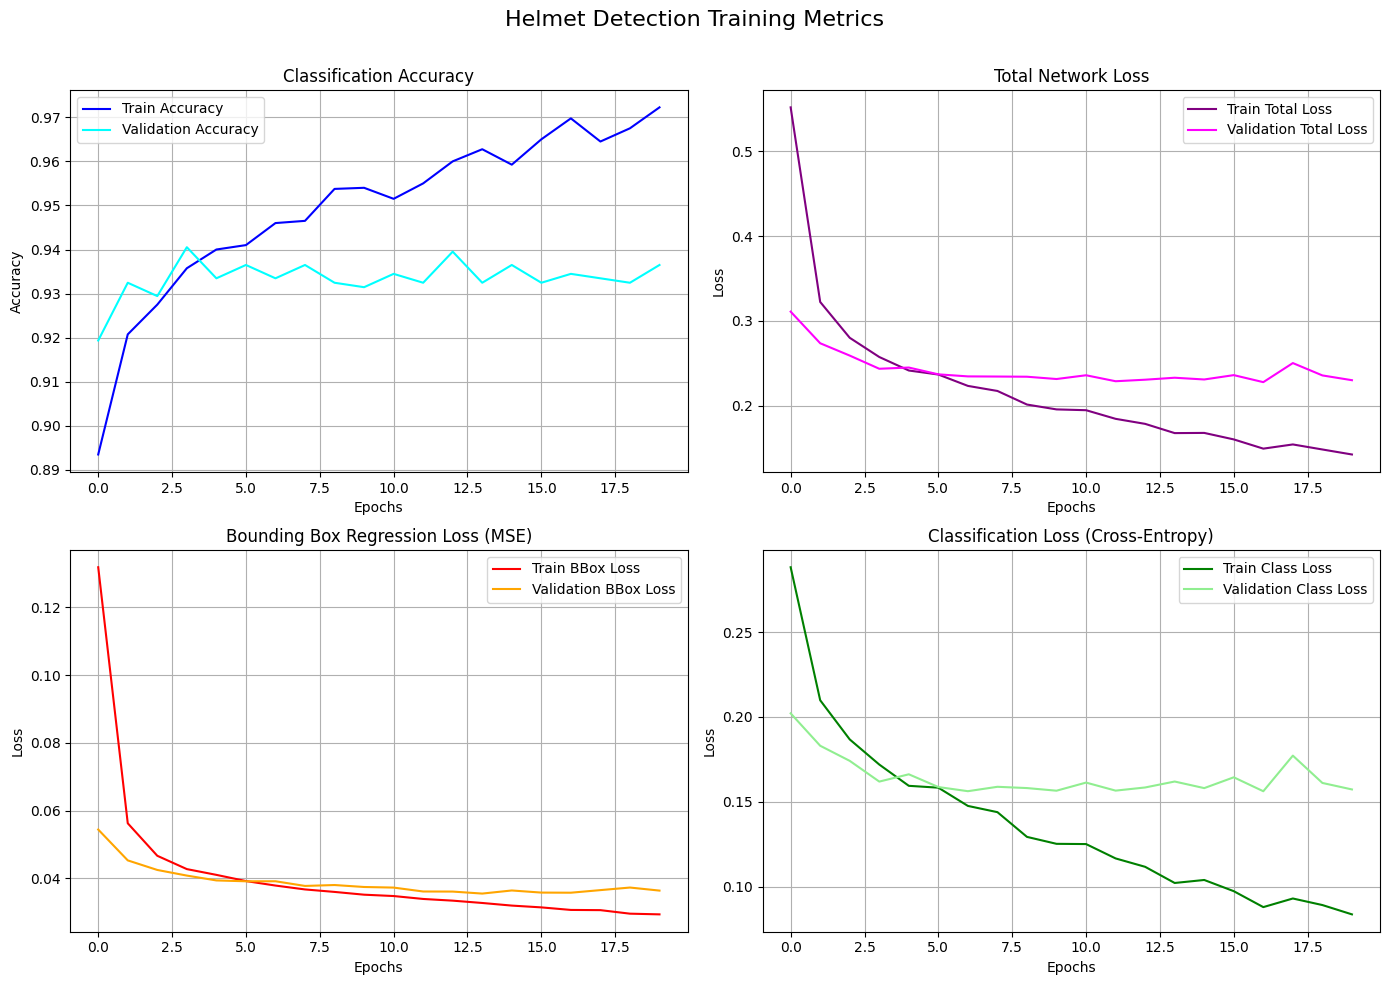

In [ ]:
import matplotlib.pyplot as plt

# The history object contains a dictionary of all recorded metrics
h = history.history

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Helmet Detection Training Metrics', fontsize=16)

# ---------------------------------------------------
# 1. Classification Accuracy (Is it a head or helmet?)
# ---------------------------------------------------
axes[0, 0].plot(h['class_output_accuracy'], label='Train Accuracy', color='blue')
axes[0, 0].plot(h['val_class_output_accuracy'], label='Validation Accuracy', color='cyan')
axes[0, 0].set_title('Classification Accuracy')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# ---------------------------------------------------
# 2. Total Combined Loss (The metric the optimizer minimizes)
# ---------------------------------------------------
axes[0, 1].plot(h['loss'], label='Train Total Loss', color='purple')
axes[0, 1].plot(h['val_loss'], label='Validation Total Loss', color='magenta')
axes[0, 1].set_title('Total Network Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# ---------------------------------------------------
# 3. Bounding Box Loss (How tight are the coordinates?)
# ---------------------------------------------------
axes[1, 0].plot(h['bbox_output_loss'], label='Train BBox Loss', color='red')
axes[1, 0].plot(h['val_bbox_output_loss'], label='Validation BBox Loss', color='orange')
axes[1, 0].set_title('Bounding Box Regression Loss (MSE)')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# ---------------------------------------------------
# 4. Classification Loss
# ---------------------------------------------------
axes[1, 1].plot(h['class_output_loss'], label='Train Class Loss', color='green')
axes[1, 1].plot(h['val_class_output_loss'], label='Validation Class Loss', color='lightgreen')
axes[1, 1].set_title('Classification Loss (Cross-Entropy)')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
import tensorflow as tf

# Load the saved model
loaded_detector = tf.keras.models.load_model('best_helmet_detector.keras')

# Verify it loaded correctly
loaded_detector.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 2)         │        258 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        260 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,268,116 (12.47 MB)

 Trainable params: 336,710 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 673,422 (2.57 MB)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report


true_classes = []
pred_classes = []

print("Running safe evaluation. This might take a minute...")


for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]


    true_batch = y_batch['class_output']
    true_classes.extend(true_batch)


    preds = loaded_detector.predict(X_batch, verbose=0)


    if isinstance(preds, dict):
        class_probs = preds['class_output']
    else:
        class_probs = preds[0]


    pred_batch = np.argmax(class_probs, axis=1)
    pred_classes.extend(pred_batch)

true_classes = np.array(true_classes)
pred_classes = np.array(pred_classes)


print("\n--- Classification Report ---")
print(classification_report(true_classes, pred_classes, target_names=['Helmet', 'Head']))

Running safe evaluation. This might take a minute...

--- Classification Report ---
              precision    recall  f1-score   support

      Helmet       0.96      0.97      0.96       868
        Head       0.76      0.71      0.73       124

    accuracy                           0.94       992
   macro avg       0.86      0.84      0.85       992
weighted avg       0.93      0.94      0.93       992



ssdad



In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('best_helmet_detector.keras')

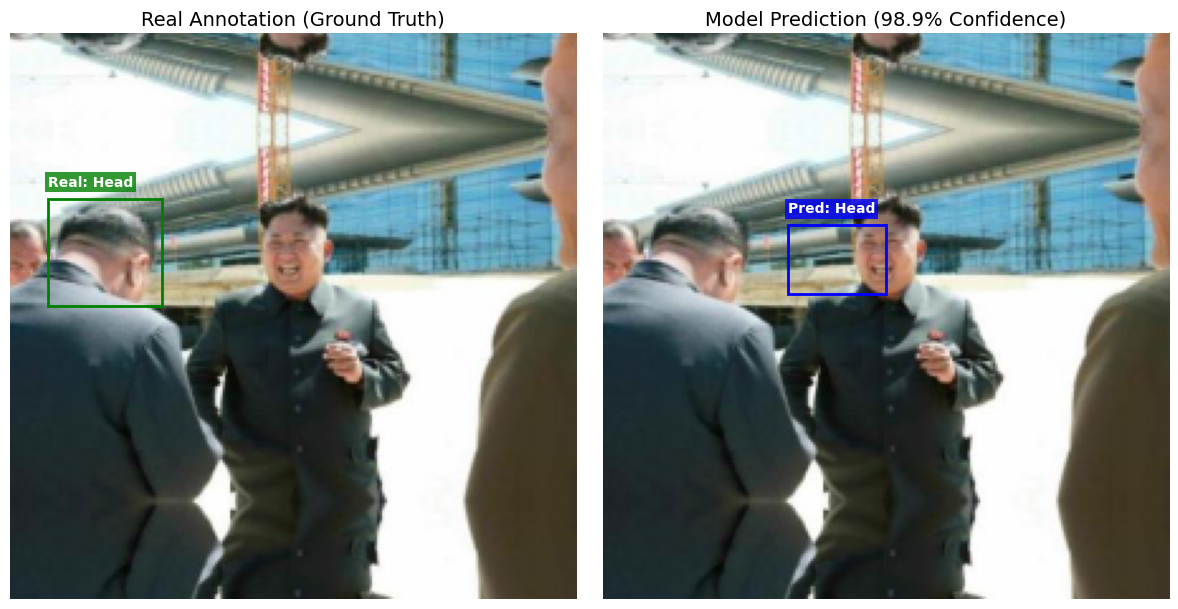

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# 1. Grab a random batch from the validation generator
random_batch_index = random.randint(0, len(val_gen) - 1)
X_batch, y_batch = val_gen[random_batch_index]

# Pick the first image in that batch
img = X_batch[0]
true_class_idx = y_batch['class_output'][0]
true_bbox = y_batch['bbox_output'][0]

# 2. Make a prediction using the model
# We use np.expand_dims to change shape from (224, 224, 3) to (1, 224, 224, 3) for the model
preds = model.predict(np.expand_dims(img, axis=0), verbose=0)

# Safely extract predictions (handling dict vs list returns)
if isinstance(preds, dict):
    pred_class_probs = preds['class_output'][0]
    pred_bbox = preds['bbox_output'][0]
else:
    pred_class_probs = preds[0][0]
    pred_bbox = preds[1][0]

pred_class_idx = np.argmax(pred_class_probs)
confidence = np.max(pred_class_probs)

# Class mapping for the labels
class_names = {0: 'Helmet', 1: 'Head'}

# 3. Helper function to draw bounding boxes
def draw_box(ax, bbox, color, label):
    # The generator normalized the boxes between 0 and 1.
    # We multiply by 224 (our image size) to get exact pixel coordinates.
    xmin, ymin, xmax, ymax = bbox * 224
    width = xmax - xmin
    height = ymax - ymin

    # Create a Rectangle patch
    rect = patches.Rectangle((xmin, ymin), width, height,
                             linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

    # Add text label above the box
    ax.text(xmin, ymin - 5, label, color='white', fontsize=10, weight='bold',
            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none'))

# 4. Plotting Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Left Plot: Ground Truth ---
axes[0].imshow(img)
axes[0].set_title("Real Annotation (Ground Truth)", fontsize=14)
draw_box(axes[0], true_bbox, color='green', label=f"Real: {class_names[true_class_idx]}")
axes[0].axis('off')

# --- Right Plot: Model Prediction ---
axes[1].imshow(img)
axes[1].set_title(f"Model Prediction ({confidence*100:.1f}% Confidence)", fontsize=14)

# Color code the prediction (Red if wrong class, Blue if correct)
pred_color = 'blue' if pred_class_idx == true_class_idx else 'red'
draw_box(axes[1], pred_bbox, color=pred_color, label=f"Pred: {class_names[pred_class_idx]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

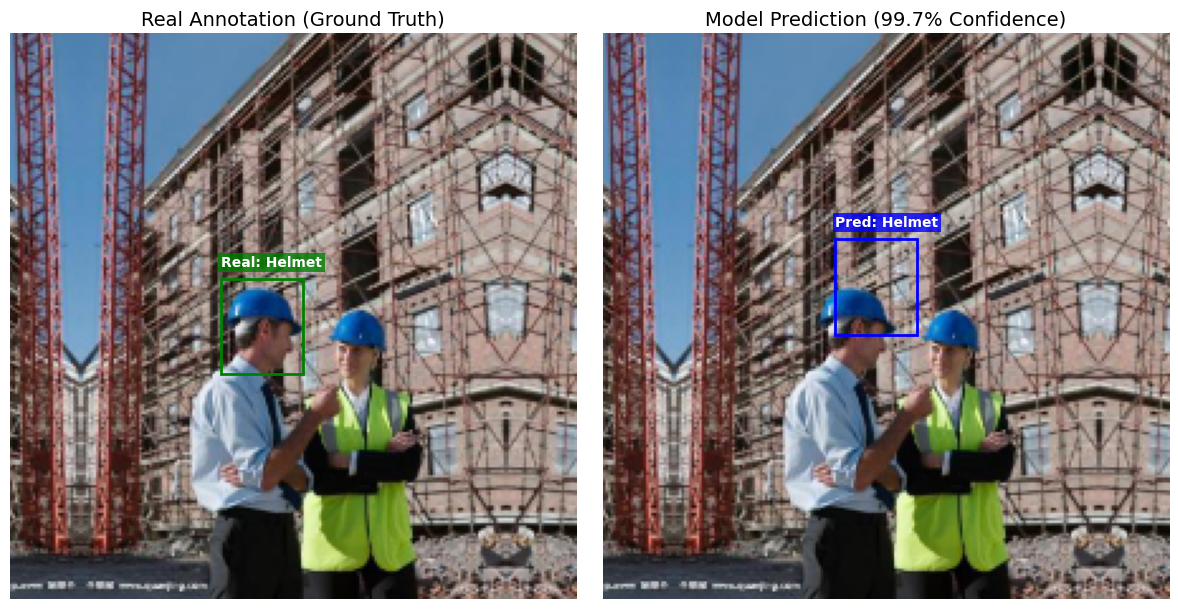

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# 1. Grab a random batch from the validation generator
random_batch_index = random.randint(0, len(val_gen) - 1)
X_batch, y_batch = val_gen[random_batch_index]

# Pick the first image in that batch
img = X_batch[0]
true_class_idx = y_batch['class_output'][0]
true_bbox = y_batch['bbox_output'][0]

# 2. Make a prediction using the model
# We use np.expand_dims to change shape from (224, 224, 3) to (1, 224, 224, 3) for the model
preds = model.predict(np.expand_dims(img, axis=0), verbose=0)

# Safely extract predictions (handling dict vs list returns)
if isinstance(preds, dict):
    pred_class_probs = preds['class_output'][0]
    pred_bbox = preds['bbox_output'][0]
else:
    pred_class_probs = preds[0][0]
    pred_bbox = preds[1][0]

pred_class_idx = np.argmax(pred_class_probs)
confidence = np.max(pred_class_probs)

# Class mapping for the labels
class_names = {0: 'Helmet', 1: 'Head'}

# 3. Helper function to draw bounding boxes
def draw_box(ax, bbox, color, label):
    # The generator normalized the boxes between 0 and 1.
    # We multiply by 224 (our image size) to get exact pixel coordinates.
    xmin, ymin, xmax, ymax = bbox * 224
    width = xmax - xmin
    height = ymax - ymin

    # Create a Rectangle patch
    rect = patches.Rectangle((xmin, ymin), width, height,
                             linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

    # Add text label above the box
    ax.text(xmin, ymin - 5, label, color='white', fontsize=10, weight='bold',
            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none'))

# 4. Plotting Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Left Plot: Ground Truth ---
axes[0].imshow(img)
axes[0].set_title("Real Annotation (Ground Truth)", fontsize=14)
draw_box(axes[0], true_bbox, color='green', label=f"Real: {class_names[true_class_idx]}")
axes[0].axis('off')

# --- Right Plot: Model Prediction ---
axes[1].imshow(img)
axes[1].set_title(f"Model Prediction ({confidence*100:.1f}% Confidence)", fontsize=14)

# Color code the prediction (Red if wrong class, Blue if correct)
pred_color = 'blue' if pred_class_idx == true_class_idx else 'red'
draw_box(axes[1], pred_bbox, color=pred_color, label=f"Pred: {class_names[pred_class_idx]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Ιmage classification dataset

In [4]:
import os
import cv2
import xml.etree.ElementTree as ET


base_dir = path
images_dir = os.path.join(base_dir, "images")
annotations_dir = os.path.join(base_dir, "annotations")


output_dir = "/content/classification_dataset"
classes = ['helmet', 'head']

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

print("Extracting and cropping features. This will take a moment...")

crop_count = {'helmet': 0, 'head': 0}


for xml_file in os.listdir(annotations_dir):
    if not xml_file.endswith('.xml'): continue

    xml_path = os.path.join(annotations_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()


    img_filename = root.find('filename').text
    img_path = os.path.join(images_dir, img_filename)
    img = cv2.imread(img_path)

    if img is None: continue

    for obj in root.findall('object'):
        name = obj.find('name').text
        if name in classes:
            bndbox = obj.find('bndbox')
            xmin = int(float(bndbox.find('xmin').text))
            ymin = int(float(bndbox.find('ymin').text))
            xmax = int(float(bndbox.find('xmax').text))
            ymax = int(float(bndbox.find('ymax').text))


            crop = img[ymin:ymax, xmin:xmax]


            if crop.size > 0:
                crop_name = f"{img_filename.split('.')[0]}_crop_{crop_count[name]}.jpg"
                save_path = os.path.join(output_dir, name, crop_name)
                cv2.imwrite(save_path, crop)
                crop_count[name] += 1

print("\nDataset successfully converted for pure classification!")
print(f"Total Helmets Extracted: {crop_count['helmet']}")
print(f"Total Bare Heads Extracted: {crop_count['head']}")

Extracting and cropping features. This will take a moment...

Dataset successfully converted for pure classification!
Total Helmets Extracted: 18966
Total Bare Heads Extracted: 5785


In [5]:
total_samples = 18966 + 5785
num_classes = 2
weight_for_helmet = (1 / 18966) * (total_samples / num_classes)
weight_for_head = (1 / 5785) * (total_samples / num_classes)
class_weights = {
    0: weight_for_helmet,
    1: weight_for_head
}

# Load The Dataset

In [6]:
import tensorflow as tf

data_dir = "/content/classification_dataset"
batch_size = 4
img_size = (224, 224)

print("Loading Training Set:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

print("\nLoading Validation Set:")
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)


class_names = train_ds.class_names
print(f"\nClass mapping: 0 = {class_names[0]}, 1 = {class_names[1]}")


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Loading Training Set:
Found 24751 files belonging to 2 classes.
Using 19801 files for training.

Loading Validation Set:
Found 24751 files belonging to 2 classes.
Using 4950 files for validation.

Class mapping: 0 = head, 1 = helmet


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Rescaling, GlobalAveragePooling2D, Dense, Dropout, Conv2D, Multiply, Lambda
from tensorflow.keras.models import Model


inputs = Input(shape=(224, 224, 3))
x = Rescaling(1./127.5, offset=-1)(inputs)


base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False


x = base_model.output

ap = GlobalAveragePooling2D()(x)

attention_probs = Dense(64, activation='relu')(ap)

attention_probs = Dense(1280, activation='sigmoid')(attention_probs)

attention_probs = tf.keras.layers.Reshape((1, 1, 1280))(attention_probs)

attended_output = Multiply()([x, attention_probs])



x = GlobalAveragePooling2D()(attended_output)
x = Dense(256, activation='relu')(x)
output_layer = Dense(len(classes), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output_layer)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,751,618 (10.50 MB)

 Trainable params: 493,634 (1.88 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('helmet_classifier_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 104s 16ms/step - accuracy: 0.8222 - loss: 0.3464 - val_accuracy: 0.8432 - val_loss: 0.3717
Epoch 2/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 67s 13ms/step - accuracy: 0.8556 - loss: 0.2899 - val_accuracy: 0.8770 - val_loss: 0.2983
Epoch 3/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.8710 - loss: 0.2667 - val_accuracy: 0.8622 - val_loss: 0.3385
Epoch 4/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 56s 11ms/step - accuracy: 0.8783 - loss: 0.2521 - val_accuracy: 0.8772 - val_loss: 0.2973
Epoch 5/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 69s 14ms/step - accuracy: 0.8877 - loss: 0.2380 - val_accuracy: 0.8919 - val_loss: 0.2739
Epoch 6/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 58s 11ms/step - accuracy: 0.8941 - loss: 0.2265 - val_accuracy: 0.8836 - val_loss: 0.2963
Epoch 7/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 83s 12ms/step - accuracy: 0.9005 - loss: 0.2148 - val_accuracy: 0.8994 - val_loss: 0.2548
Epoch 8/10
4951/4951 ━━━━━━━━━━━━━━━━━━━━ 59s 11ms/step - accuracy: 0.9054 

In [ ]:
model = tf.keras.models.load_model('helmet_classifier_best.keras')

Extracting predictions from the validation set...

--- Classification Report ---
              precision    recall  f1-score   support

        head       0.87      0.65      0.75      1128
      helmet       0.90      0.97      0.94      3822

    accuracy                           0.90      4950
   macro avg       0.89      0.81      0.84      4950
weighted avg       0.90      0.90      0.89      4950



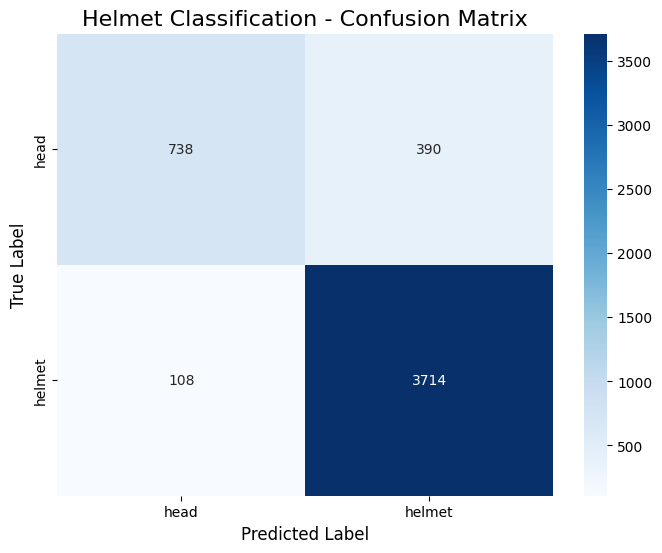

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Extracting predictions from the validation set...")

true_classes = []
pred_classes = []


for images, labels in val_ds:

    true_classes.extend(labels.numpy())


    preds = model.predict(images, verbose=0)


    batch_preds = np.argmax(preds, axis=1)
    pred_classes.extend(batch_preds)


true_classes = np.array(true_classes)
pred_classes = np.array(pred_classes)


class_names = ['head', 'helmet']


print("\n--- Classification Report ---")
print(classification_report(true_classes, pred_classes, target_names=class_names))


cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Helmet Classification - Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

### Prediction on a Sample Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step


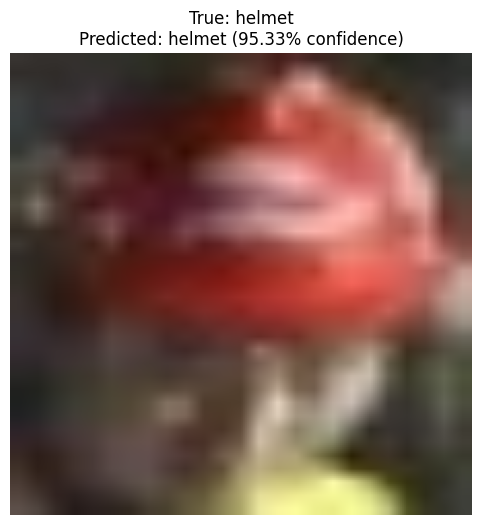

In [8]:
import numpy as np
import matplotlib.pyplot as plt

for images, labels in val_ds.take(1):

    sample_image = images[0].numpy()
    true_label = labels[0].numpy()
    break

input_image = np.expand_dims(sample_image, axis=0)

predictions = model.predict(input_image)

predicted_class_idx = np.argmax(predictions)
confidence = np.max(predictions)


predicted_class_name = class_names[predicted_class_idx]
true_class_name = class_names[true_label]


plt.figure(figsize=(6, 6))

plt.imshow(sample_image / 255.0)
plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name} ({confidence*100:.2f}% confidence)")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step


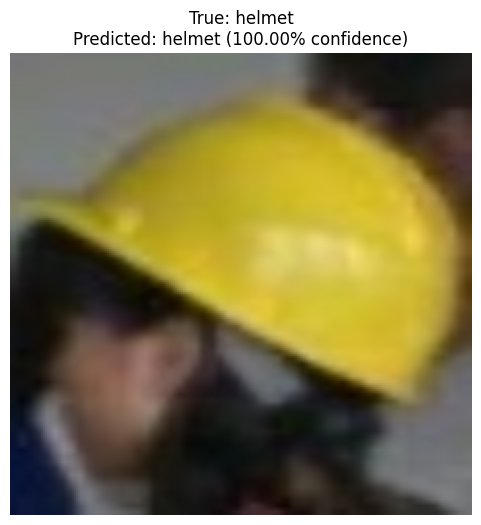

In [9]:
for images, labels in val_ds.take(1):

    sample_image = images[2].numpy()
    true_label = labels[2].numpy()
    break

input_image = np.expand_dims(sample_image, axis=0)

predictions = model.predict(input_image)

predicted_class_idx = np.argmax(predictions)
confidence = np.max(predictions)


predicted_class_name = class_names[predicted_class_idx]
true_class_name = class_names[true_label]


plt.figure(figsize=(6, 6))

plt.imshow(sample_image / 255.0)
plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name} ({confidence*100:.2f}% confidence)")
plt.axis('off')
plt.show()

In [13]:
preds=model.predict(input_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step


In [18]:
tf.argmax(preds,axis=1)

<tf.Tensor: shape=(1,), dtype=int64, numpy=array([1])>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step


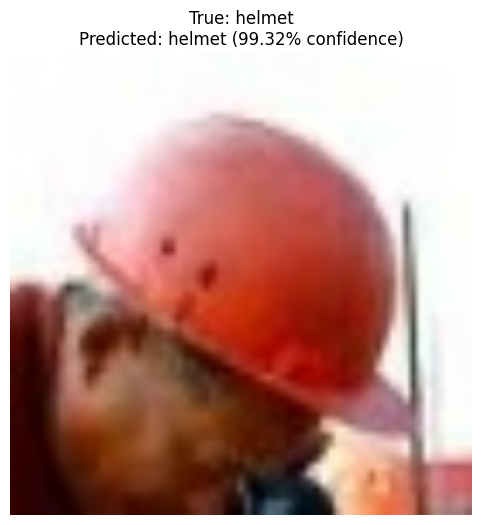

In [20]:
for images, labels in val_ds.take(1):

    sample_image = images[3].numpy()
    true_label = labels[3].numpy()
    break

input_image = np.expand_dims(sample_image, axis=0)

predictions = model.predict(input_image)

predicted_class_idx = np.argmax(predictions)
confidence = np.max(predictions)


predicted_class_name = class_names[predicted_class_idx]
true_class_name = class_names[true_label]


plt.figure(figsize=(6, 6))

plt.imshow(sample_image / 255.0)
plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name} ({confidence*100:.2f}% confidence)")
plt.axis('off')
plt.show()

# Make it to tf.js

In [ ]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting u

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('helmet_classifier_best.keras')


model.save('attention_classifier_best.h5')

print("Model successfully saved as .h5!")

Model successfully saved as .h5!


In [ ]:
!tensorflowjs_converter \
  --input_format=keras \
  attention_classifier_best.h5 \
  tfjs-model/

2026-06-06 11:32:56.116143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780745576.150484    3614 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780745576.162186    3614 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780745576.193742    3614 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780745576.197870    3614 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780745576.199193    3614 computation_placer.cc:177] computation placer alr

In [ ]:

class_names = ['helmet_off', 'helmet_on', 'vest_on']

with open('tfjs-model/labels.txt', 'w') as f:
    for label in class_names:
        f.write(f"{label}\n")

print("labels.txt generated successfully!")

labels.txt generated successfully!


In [ ]:
import shutil
from google.colab import files


shutil.make_archive('tfjs_deliverable', 'zip', 'tfjs-model')

files.download('tfjs_deliverable.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>